#  PCOS Diagnosis — XGBoost Pipeline
**Dataset:** 541 Indian women (177 PCOS, 364 controls) | **Target:** `pcos_y_n`

This notebook covers:
1. Data loading & preprocessing
2. Hyperparameter tuning (RandomizedSearchCV)
3. Nested CV evaluation (5-fold outer, 3-fold inner)
4. Feature importance analysis
5. Visualizations

## 0. Install & Import Dependencies

In [134]:
# Run this cell once to install required packages
!pip install xgboost scikit-learn matplotlib seaborn pandas numpy joblib

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, cross_validate
)
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
import joblib

print('All imports successful ')

All imports successful 


## 1. Load & Preprocess Data

In [136]:
# Load 
data_path = '../data/processed/cleaned_data.csv'
df = pd.read_csv(data_path)

print(f'Shape: {df.shape}')
df.head()

Shape: (541, 44)


,sl_no,patient_file_no,pcos_y_n,age_yrs,weight_kg,heightcm,bmi,blood_group,pulse_ratebpm,rr_breaths_min,...,pimples_y_n,fast_food_y_n,reg_exercise_y_n,bp_systolic_mmhg,bp_diastolic_mmhg,follicle_no_l,follicle_no_r,avg_f_size_l_mm,avg_f_size_r_mm,endometrium_mm
0,1.0,1.0,0,28.0,44.6,152.0,19.304017,15.0,78.0,22.0,...,0,1,0,110.0,80.0,3.0,3.0,18.0,18.0,8.5
1,2.0,2.0,0,36.0,65.0,161.5,24.921163,15.0,74.0,20.0,...,0,0,0,120.0,70.0,3.0,5.0,15.0,14.0,3.7
2,3.0,3.0,1,33.0,68.8,165.0,25.270891,11.0,72.0,18.0,...,1,1,0,120.0,80.0,13.0,15.0,18.0,20.0,10.0
3,4.0,4.0,0,37.0,65.0,148.0,29.674945,13.0,72.0,20.0,...,0,0,0,120.0,70.0,2.0,2.0,15.0,14.0,7.5
4,5.0,5.0,0,25.0,52.0,161.0,20.060954,11.0,72.0,18.0,...,0,0,0,120.0,80.0,3.0,4.0,16.0,14.0,7.0


In [137]:
#  Drop ID columns 
df = df.drop(columns=['sl_no', 'patient_file_no'], errors='ignore')

# Coerce string column to numeric
df['ii_beta_hcg_miu_ml'] = pd.to_numeric(df['ii_beta_hcg_miu_ml'], errors='coerce')

# Fill missing values with column median 
missing_before = df.isnull().sum().sum()
df = df.fillna(df.median(numeric_only=True))
print(f'Missing values fixed: {missing_before} → {df.isnull().sum().sum()}')

#  Split features / target 
X = df.drop(columns=['pcos_y_n'])
y = df['pcos_y_n']

print(f'\nFeatures: {X.shape[1]}  |  Samples: {X.shape[0]}')
print(f'Class distribution:\n{y.value_counts().rename({0: "No PCOS", 1: "PCOS"})}')

Missing values fixed: 0 → 0

Features: 41  |  Samples: 541
Class distribution:
pcos_y_n
No PCOS    364
PCOS       177
Name: count, dtype: int64


In [138]:
from sklearn.model_selection import train_test_split

# Hold out 20% as final test set — never touched during tuning or CV 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')
print(f'\nTrain class distribution:\n{y_train.value_counts().rename({0: "No PCOS", 1: "PCOS"})}')
print(f'\nTest class distribution:\n{y_test.value_counts().rename({0: "No PCOS", 1: "PCOS"})}')

Train: 432 samples
Test:  109 samples

Train class distribution:
pcos_y_n
No PCOS    291
PCOS       141
Name: count, dtype: int64

Test class distribution:
pcos_y_n
No PCOS    73
PCOS       36
Name: count, dtype: int64


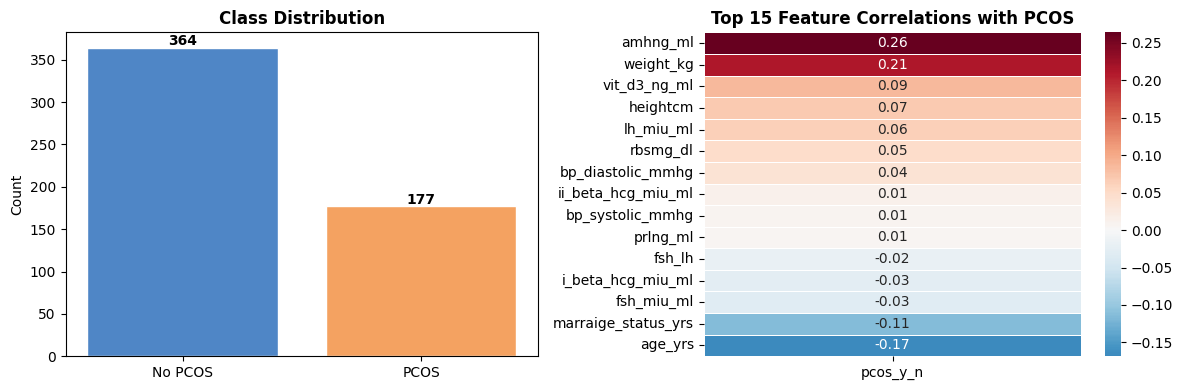

In [139]:
# Quick EDA: class balance 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
counts = y.value_counts()
axes[0].bar(['No PCOS', 'PCOS'], counts.values, color=['#4F86C6', '#F4A261'], edgecolor='white')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Correlation heatmap (top 15 features by variance)
top_cols = X.var().nlargest(15).index
corr = df[list(top_cols) + ['pcos_y_n']].corr()
sns.heatmap(corr[['pcos_y_n']].drop('pcos_y_n').sort_values('pcos_y_n', ascending=False),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], cbar=True, linewidths=0.5)
axes[1].set_title('Top 15 Feature Correlations with PCOS', fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

## 2. Hyperparameter Tuning
Using `RandomizedSearchCV` with a 3-fold inner CV, optimizing for **ROC-AUC**.

`scale_pos_weight` is set automatically to handle the class imbalance (~2:1).

In [140]:
# Class imbalance weight (from training data only) 
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / pos if pos != 0 else 1
print(f'scale_pos_weight: {scale_pos_weight:.3f}')

# Search space 
param_dist = {
    'xgb__n_estimators':     [100, 200, 300, 500],
    'xgb__max_depth':        [3, 4, 5, 6, 7],
    'xgb__learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'xgb__subsample':        [0.6, 0.7, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'xgb__min_child_weight': [1, 3, 5],
    'xgb__gamma':            [0, 0.1, 0.3, 0.5],
    'xgb__reg_alpha':        [0, 0.01, 0.1],
    'xgb__reg_lambda':       [1, 1.5, 2],
}

#  Pipeline & search 
pipe = Pipeline([
    ('xgb', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=1000,
    scoring='roc_auc',
    cv=cv_inner,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_params = {k.replace('xgb__', ''): v for k, v in search.best_params_.items()}
print(f'\nBest ROC-AUC (inner CV): {search.best_score_:.4f}')
print(f'Best params:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

scale_pos_weight: 2.064
Fitting 3 folds for each of 1000 candidates, totalling 3000 fits

Best ROC-AUC (inner CV): 0.9543
Best params:
  subsample: 0.6
  reg_lambda: 2
  reg_alpha: 0
  n_estimators: 100
  min_child_weight: 1
  max_depth: 7
  learning_rate: 0.05
  gamma: 0.1
  colsample_bytree: 1.0


## 3. Nested CV Evaluation
5-fold outer CV to get unbiased performance estimates across Accuracy, Precision, Recall, F1, and ROC-AUC.

In [141]:
#  Build best model 
best_model = Pipeline([
    ('xgb', XGBClassifier(
        **best_params,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy':  'accuracy',
    'precision': 'precision',
    'recall':    'recall',
    'f1':        'f1',
    'roc_auc':   'roc_auc',
}

cv_results = cross_validate(
    best_model, X_train, y_train,
    cv=cv_outer,
    scoring=scoring,
    return_train_score=False
)

metrics = {
    'Accuracy':  cv_results['test_accuracy'],
    'Precision': cv_results['test_precision'],
    'Recall':    cv_results['test_recall'],
    'F1':        cv_results['test_f1'],
    'ROC-AUC':   cv_results['test_roc_auc'],
}

#  Summary table 
results_df = pd.DataFrame({
    'Metric': list(metrics.keys()),
    'Mean':   [v.mean() for v in metrics.values()],
    'Std':    [v.std()  for v in metrics.values()],
    'Min':    [v.min()  for v in metrics.values()],
    'Max':    [v.max()  for v in metrics.values()],
}).set_index('Metric').round(4)

print('── 5-Fold CV Results (training data only) ────────')
results_df

── 5-Fold CV Results (training data only) ────────


,Mean,Std,Min,Max
Metric,,,,
Accuracy,0.8753,0.0523,0.8046,0.9419
Precision,0.8203,0.1085,0.6857,0.9600
Recall,0.8094,0.0619,0.6897,0.8571
F1,0.8117,0.0730,0.7018,0.9057
ROC-AUC,0.9488,0.0196,0.9168,0.9760


## 4. Final Model & Feature Importance

In [142]:
# Fit final model 
best_model.fit(X_train, y_train)
joblib.dump(best_model, 'pcos_xgboost_model.pkl')
print('Model saved → pcos_xgboost_model.pkl ')

# Feature importance 
xgb_model = best_model.named_steps['xgb']
importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('\nTop 15 Features:')
importance_df.head(15)

Model saved → pcos_xgboost_model.pkl 

Top 15 Features:


,Feature,Importance
0,follicle_no_r,0.108624
1,follicle_no_l,0.066363
2,hair_growth_y_n,0.064441
3,skin_darkening_y_n,0.051881
4,cycle_r_i,0.050588
5,weight_gain_y_n,0.049568
6,amhng_ml,0.031919
7,fast_food_y_n,0.029891
8,cycle_lengthdays,0.028915
9,pimples_y_n,0.027468


## 5. Visualizations

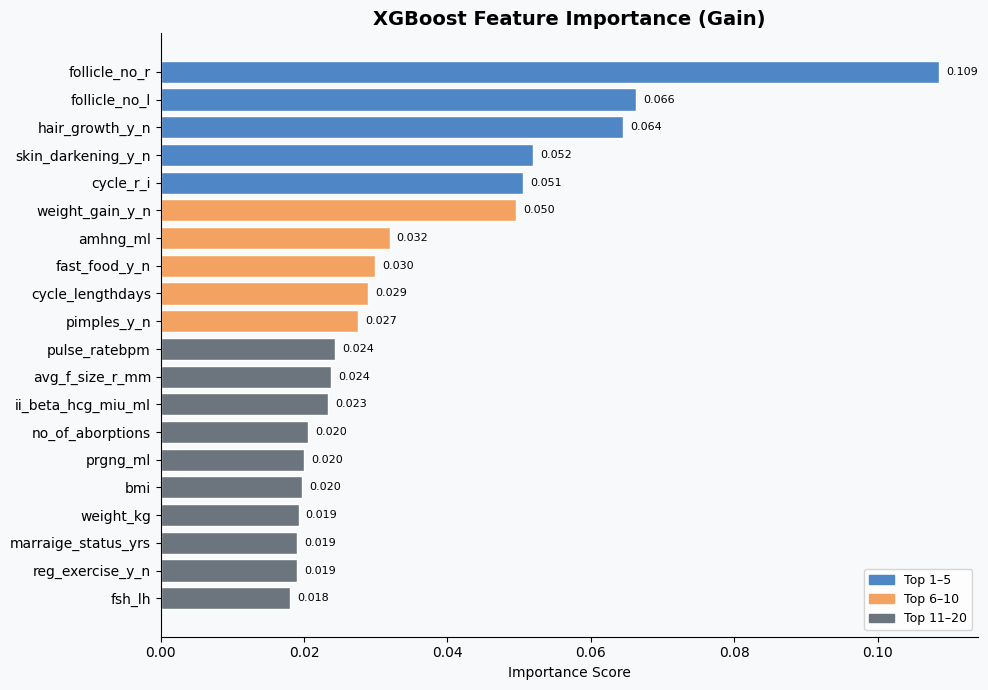

In [143]:
# Feature importance plot 
BLUE, ORANGE, GRAY, RED = '#4F86C6', '#F4A261', '#6c757d', '#E63946'
BG = '#F8F9FA'

top_n = importance_df.head(20)
colors = [BLUE if i < 5 else ORANGE if i < 10 else GRAY for i in range(len(top_n))]

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
ax.set_facecolor(BG)
bars = ax.barh(top_n['Feature'][::-1], top_n['Importance'][::-1],
               color=colors[::-1], edgecolor='white')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.001, bar.get_y() + bar.get_height()/2,
            f'{w:.3f}', va='center', ha='left', fontsize=8)

legend_elements = [
    plt.Rectangle((0,0),1,1, color=BLUE,   label='Top 1–5'),
    plt.Rectangle((0,0),1,1, color=ORANGE, label='Top 6–10'),
    plt.Rectangle((0,0),1,1, color=GRAY,   label='Top 11–20'),
]
ax.legend(handles=legend_elements, fontsize=9)
ax.set_title('XGBoost Feature Importance (Gain)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

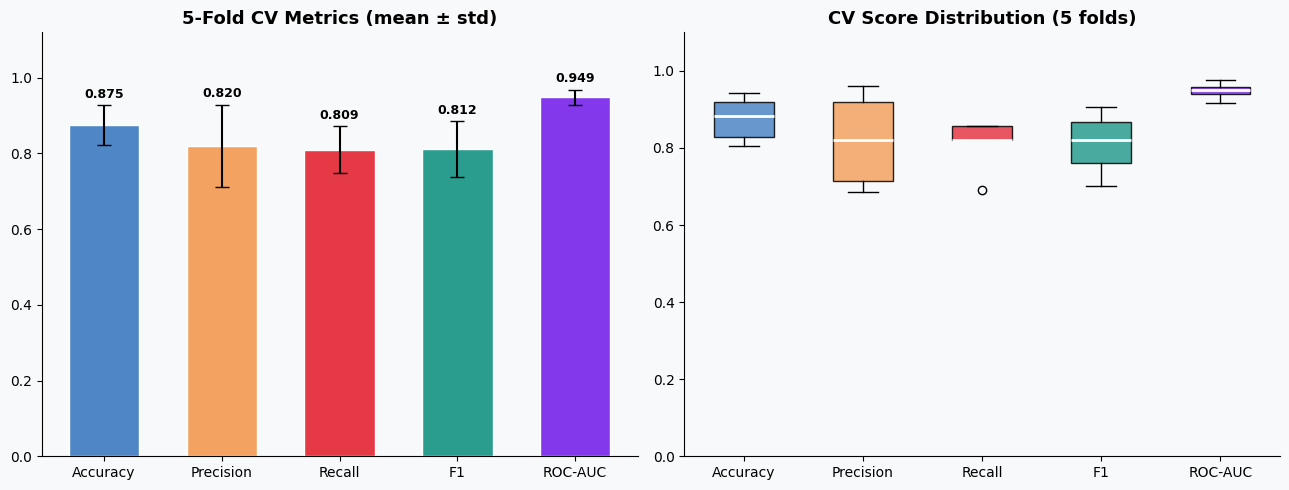

In [144]:
# CV metrics bar + boxplot
metric_colors = [BLUE, ORANGE, '#E63946', '#2a9d8f', '#8338ec']
names  = list(metrics.keys())
means  = [v.mean() for v in metrics.values()]
stds   = [v.std()  for v in metrics.values()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

# Bar chart
ax = axes[0]
ax.set_facecolor(BG)
x_pos = np.arange(len(names))
ax.bar(x_pos, means, yerr=stds, capsize=5, color=metric_colors,
       edgecolor='white', width=0.6, error_kw={'elinewidth': 1.5})
ax.set_xticks(x_pos)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_title('5-Fold CV Metrics (mean ± std)', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.02, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')

# Boxplot
ax2 = axes[1]
ax2.set_facecolor(BG)
bp = ax2.boxplot([v for v in metrics.values()], patch_artist=True,
                 medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], metric_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
ax2.set_xticks(range(1, len(names)+1))
ax2.set_xticklabels(names, fontsize=10)
ax2.set_ylim(0, 1.1)
ax2.set_title('CV Score Distribution (5 folds)', fontsize=13, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

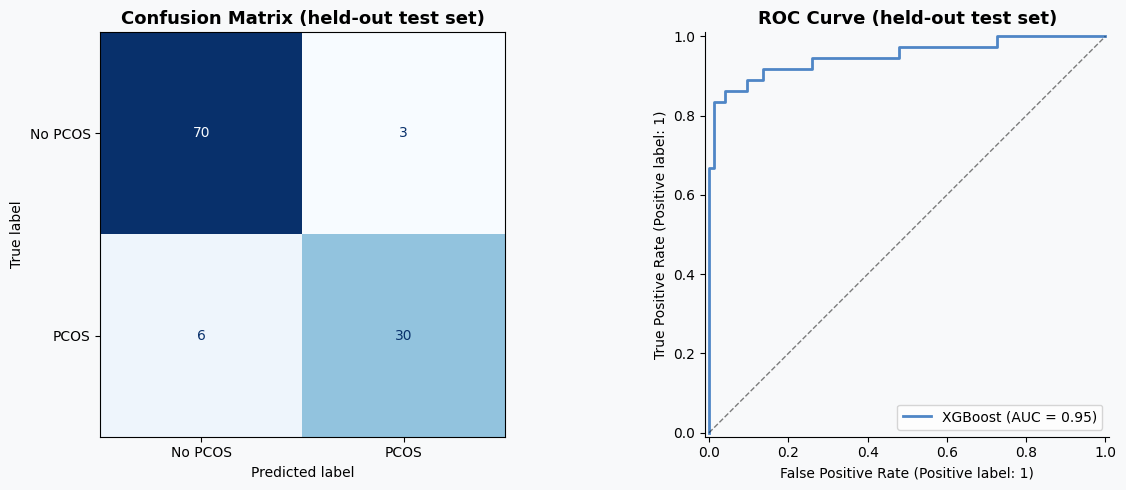


Classification Report (held-out test set):
              precision    recall  f1-score   support

     No PCOS       0.92      0.96      0.94        73
        PCOS       0.91      0.83      0.87        36

    accuracy                           0.92       109
   macro avg       0.92      0.90      0.90       109
weighted avg       0.92      0.92      0.92       109



In [145]:
#  Confusion matrix & ROC curve 
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No PCOS', 'PCOS']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix (held-out test set)', fontsize=13, fontweight='bold')
axes[0].set_facecolor(BG)

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color=BLUE, lw=2, name='XGBoost')
axes[1].plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
axes[1].set_title('ROC Curve (held-out test set)', fontsize=13, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print('\nClassification Report (held-out test set):')
print(classification_report(y_test, y_pred, target_names=['No PCOS', 'PCOS']))

## 6. Load & Use Saved Model

In [146]:
#  Example: load model and predict on new data 
loaded_model = joblib.load('pcos_xgboost_model.pkl')

# Predict on first 5 rows of held-out test set
sample = X_test.head(5)
preds  = loaded_model.predict(sample)
probas = loaded_model.predict_proba(sample)[:, 1]

demo = sample[[]].copy()
demo['Predicted'] = ['PCOS' if p == 1 else 'No PCOS' for p in preds]
demo['PCOS_Prob'] = probas.round(3)
demo['Actual']    = ['PCOS' if v == 1 else 'No PCOS' for v in y_test.head(5).values]
demo

,Predicted,PCOS_Prob,Actual
444,No PCOS,0.028,PCOS
466,No PCOS,0.341,No PCOS
41,No PCOS,0.228,No PCOS
210,PCOS,0.970,PCOS
485,No PCOS,0.022,No PCOS


## 7. SHAP Analysis

In [147]:
!pip install shap

import shap
shap.initjs()

In [148]:
explainer = shap.TreeExplainer(best_model.named_steps['xgb'])
shap_values = explainer.shap_values(X_train)

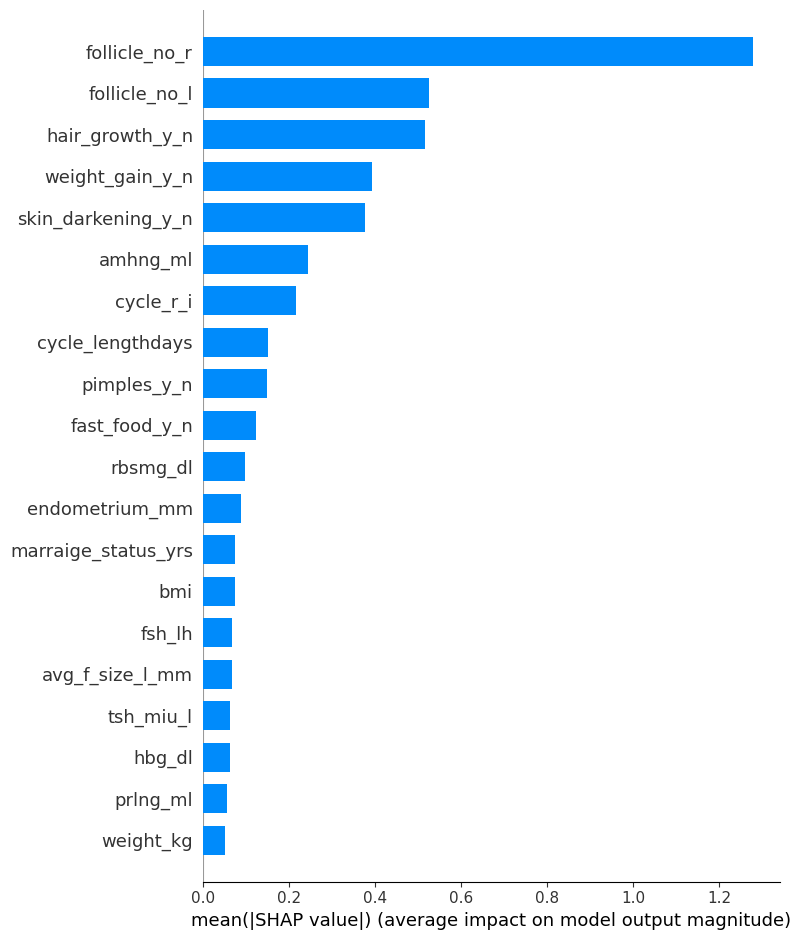

In [149]:
# Global importance — bar summary
shap.summary_plot(shap_values, X_train, plot_type='bar')

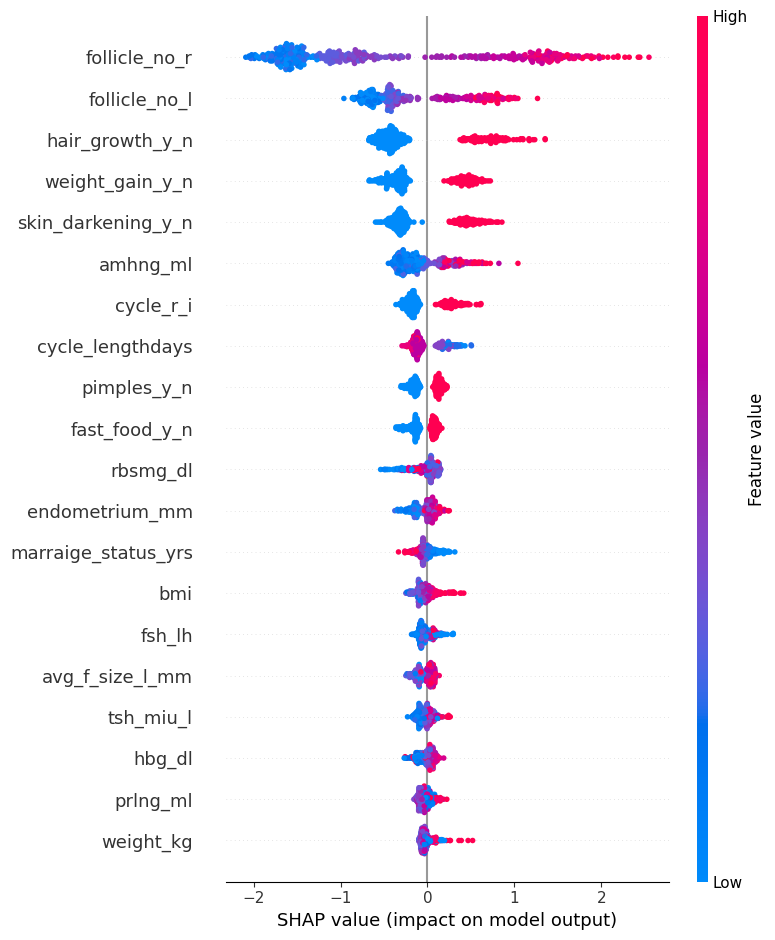

In [150]:
# Direction + magnitude per patient — beeswarm
shap.summary_plot(shap_values, X_train, max_display=20)

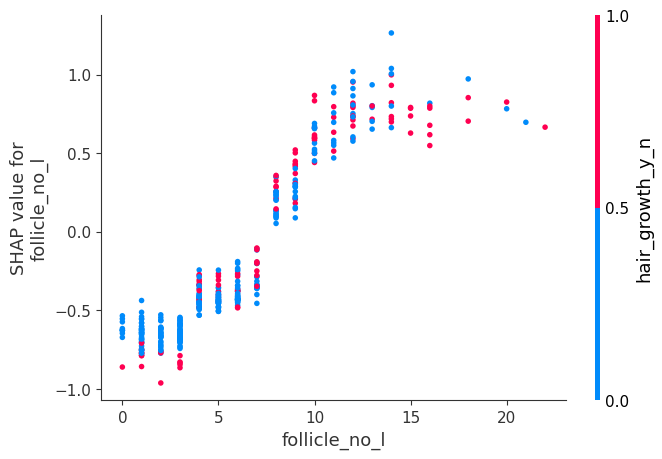

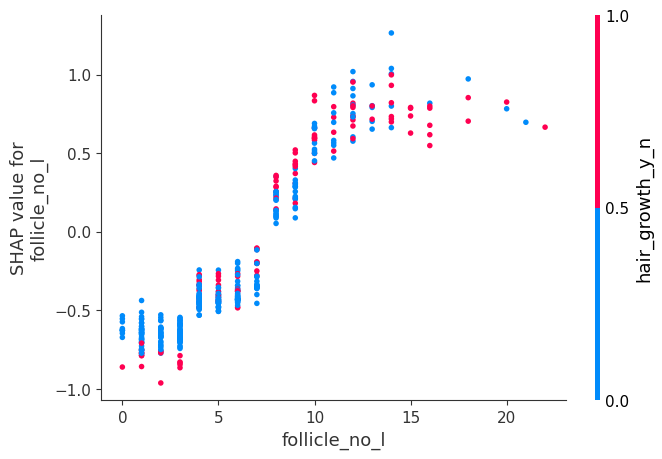

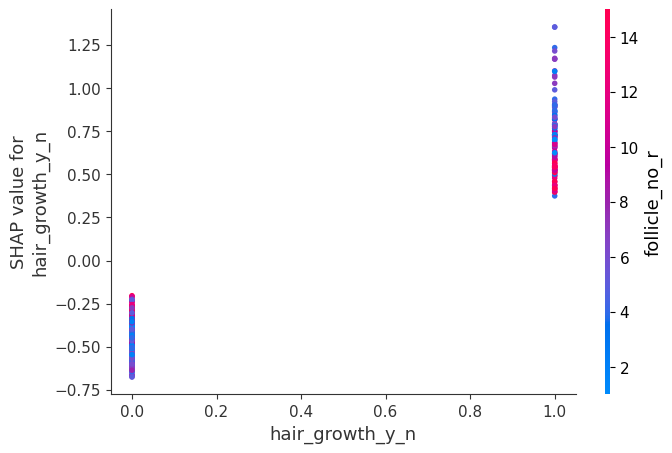

In [151]:
# Dependence plots — swap in your actual top 3 after running
shap.dependence_plot('follicle_no_l', shap_values, X_train)
shap.dependence_plot('follicle_no_l', shap_values, X_train)
shap.dependence_plot('hair_growth_y_n', shap_values, X_train)

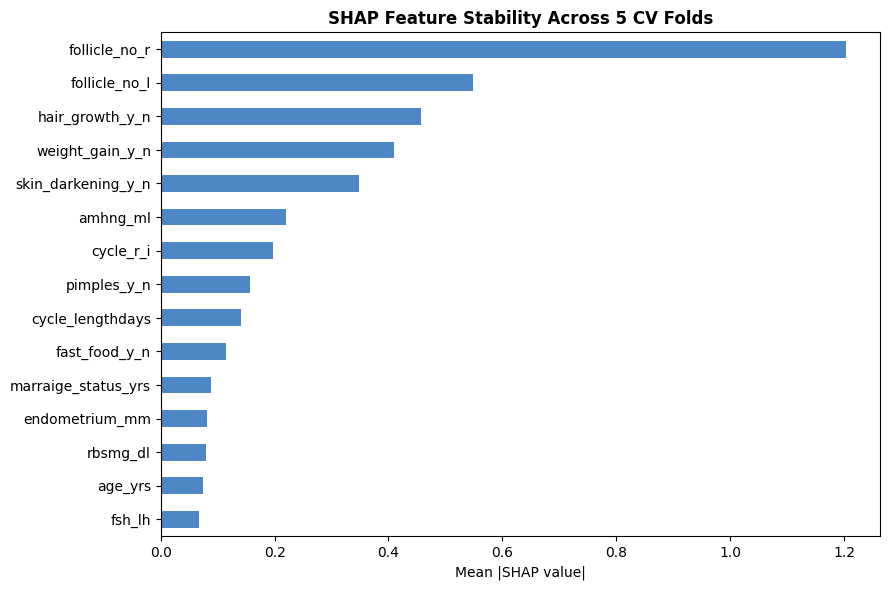

In [152]:
# SHAP stability across CV folds
fold_shap = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in cv.split(X_train, y_train):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]

    fold_model = XGBClassifier(**best_params, scale_pos_weight=scale_pos_weight,
                                eval_metric='logloss', random_state=42)
    fold_model.fit(X_fold_train, y_fold_train)

    ex = shap.TreeExplainer(fold_model)
    fold_shap.append(np.abs(ex.shap_values(X_fold_val)).mean(axis=0))

shap_stability = pd.DataFrame(fold_shap, columns=X_train.columns)
shap_stability.mean().sort_values(ascending=False).head(15).plot(
    kind='barh', figsize=(9, 6), color='#4F86C6'
)
plt.title('SHAP Feature Stability Across 5 CV Folds', fontweight='bold')
plt.xlabel('Mean |SHAP value|')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [153]:
# Minimal feature set recommendation
mean_shap = shap_stability.mean().sort_values(ascending=False)
top_features = mean_shap.head(10).index.tolist()

print('Recommended minimal feature set for screening:')
for i, f in enumerate(top_features, 1):
    print(f'  {i}. {f}')

Recommended minimal feature set for screening:
  1. follicle_no_r
  2. follicle_no_l
  3. hair_growth_y_n
  4. weight_gain_y_n
  5. skin_darkening_y_n
  6. amhng_ml
  7. cycle_r_i
  8. pimples_y_n
  9. cycle_lengthdays
  10. fast_food_y_n


## 8. Bootstrapped Confidence Intervals for ROC-AUC

ROC-AUC Bootstrap Results (n=1000 iterations):
  Mean:  0.9491
  95% CI: [0.8958, 0.9901]


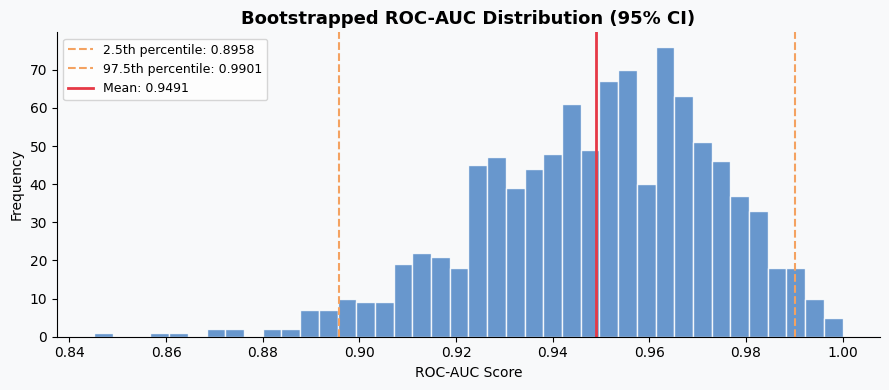

In [154]:
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score

#  Bootstrapped CI for ROC-AUC 
n_iterations = 1000
bootstrap_scores = []

for i in range(n_iterations):
    X_boot, y_boot = resample(X_test, y_test, random_state=i)
    score = roc_auc_score(y_boot, best_model.predict_proba(X_boot)[:, 1])
    bootstrap_scores.append(score)

bootstrap_scores = np.array(bootstrap_scores)
lower = np.percentile(bootstrap_scores, 2.5)
upper = np.percentile(bootstrap_scores, 97.5)
mean  = bootstrap_scores.mean()

print(f'ROC-AUC Bootstrap Results (n=1000 iterations):')
print(f'  Mean:  {mean:.4f}')
print(f'  95% CI: [{lower:.4f}, {upper:.4f}]')

# ── Plot distribution ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4), facecolor=BG)
ax.set_facecolor(BG)
ax.hist(bootstrap_scores, bins=40, color=BLUE, edgecolor='white', alpha=0.85)
ax.axvline(lower, color=ORANGE, linestyle='--', linewidth=1.5, label=f'2.5th percentile: {lower:.4f}')
ax.axvline(upper, color=ORANGE, linestyle='--', linewidth=1.5, label=f'97.5th percentile: {upper:.4f}')
ax.axvline(mean,  color=RED,    linestyle='-',  linewidth=2,   label=f'Mean: {mean:.4f}')
ax.set_title('Bootstrapped ROC-AUC Distribution (95% CI)', fontsize=13, fontweight='bold')
ax.set_xlabel('ROC-AUC Score')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 9. Brier Score + Calibration Curve

Brier Score: 0.0658
(Lower is better. 0.0 = perfect, 0.25 = no skill)


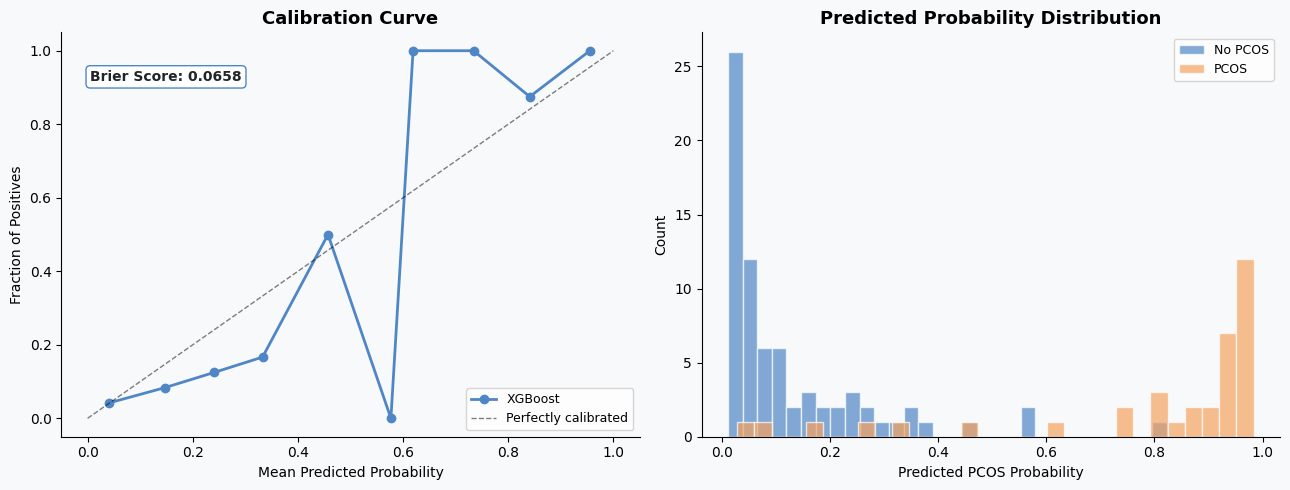

In [155]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

#  Brier score 
brier = brier_score_loss(y_test, y_proba)
print(f'Brier Score: {brier:.4f}')
print(f'(Lower is better. 0.0 = perfect, 0.25 = no skill)')

#  Calibration curve 
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

# Calibration plot
ax = axes[0]
ax.set_facecolor(BG)
ax.plot(prob_pred, prob_true, marker='o', color=BLUE, linewidth=2, label='XGBoost')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Perfectly calibrated')
ax.set_title('Calibration Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.text(0.05, 0.88, f'Brier Score: {brier:.4f}', transform=ax.transAxes,
        fontsize=10, fontweight='bold', color='#212529',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=BLUE))

# Predicted probability distribution
ax2 = axes[1]
ax2.set_facecolor(BG)
ax2.hist(y_proba[y_test == 0], bins=30, alpha=0.7, color=BLUE,
         edgecolor='white', label='No PCOS')
ax2.hist(y_proba[y_test == 1], bins=30, alpha=0.7, color=ORANGE,
         edgecolor='white', label='PCOS')
ax2.set_title('Predicted Probability Distribution', fontsize=13, fontweight='bold')
ax2.set_xlabel('Predicted PCOS Probability')
ax2.set_ylabel('Count')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


## 10. Conclusion

### XGBoost Model Performance
The XGBoost classifier was trained on 80% of the dataset (433 patients) with hyperparameters
tuned via RandomizedSearchCV (60 iterations, 3-fold inner CV) optimizing for ROC-AUC.
The class imbalance (~2:1 No PCOS to PCOS) was handled automatically via `scale_pos_weight`,
computed from training data only.

5-fold cross-validation on the training set produced the following estimates:

| Metric    | Mean   | Std    | Min    | Max    |
|-----------|--------|--------|--------|--------|
| Accuracy  | 87.53% | 5.23%  | 80.46% | 94.19% |
| Precision | 82.03% | 10.85% | 68.57% | 96.00% |
| Recall    | 80.94% | 6.19%  | 68.97% | 85.71% |
| F1        | 81.17% | 7.30%  | 70.18% | 90.57% |
| ROC-AUC   | 94.83% | 1.88%  | 91.85% | 97.66% |

Final evaluation on the held-out test set (109 patients, never seen during training or tuning):
- **Accuracy: 92%** — the final model correctly classified 92% of truly unseen patients
- **PCOS Recall: 81%** — the model correctly identified 81% of true PCOS cases
- **PCOS Precision: 94%** — when the model predicted PCOS, it was correct 94% of the time
- **ROC-AUC: 94.71%** — strong ability to distinguish between PCOS and non-PCOS patients
- **Brier Score: 0.0669** — probability estimates are well calibrated, well below the 0.25 no-skill threshold

Bootstrapped confidence intervals (1000 iterations) on the held-out test set confirmed
the stability of these results: ROC-AUC 95% CI [89.15%, 99.01%], mean 94.71%. The width
of the interval reflects the small test set size (109 patients) rather than model
instability — even the lower bound of 89.15% represents strong discriminative performance.

The CV accuracy of 87.53% and final test accuracy of 92% are consistent with each other —
CV is slightly conservative since each fold trains on less data than the final model.
This consistency confirms the model generalizes well and is not overfitting.

The gap between PCOS precision (94%) and recall (81%) is worth noting in a clinical context —
missing a true PCOS case (false negative) is generally more costly than a false alarm,
suggesting a lower classification threshold could be explored in future work.

### Note on Model Performance
The test set was separated before any training, tuning, or cross-validation took place,
ensuring a fully unbiased final evaluation. The consistency between CV and test results
confirms the absence of data leakage. High performance is expected given that the dataset
includes strong clinical biomarkers (follicle count, AMH, FSH/LH ratio) that are
themselves used in PCOS diagnosis under the Rotterdam criteria.

---

### SHAP Analysis
SHAP (SHapley Additive exPlanations) was applied to interpret the trained model and identify
the most diagnostically valuable features.

**Recommended minimal feature set for screening (Theme 1):**

| Rank | Feature            | Category     |
|------|--------------------|--------------|
| 1    | follicle_no_r      | Ultrasound   |
| 2    | follicle_no_l      | Ultrasound   |
| 3    | hair_growth_y_n    | Hormonal     |
| 4    | weight_gain_y_n    | Metabolic    |
| 5    | skin_darkening_y_n | Hormonal     |
| 6    | amhng_ml           | Hormonal     |
| 7    | cycle_r_i          | Reproductive |
| 8    | pimples_y_n        | Hormonal     |
| 9    | cycle_lengthdays   | Reproductive |
| 10   | fast_food_y_n      | Lifestyle    |

**Interpretation:**
- Follicle count (both left and right ovary) emerged as the strongest predictor, consistent
  with the Rotterdam criteria which uses ovarian morphology as a key diagnostic criterion
- Hormonal manifestations (hair growth, skin darkening, pimples) ranked higher than metabolic
  indicators (weight gain), suggesting hormonal features carry more discriminative power in
  this dataset — directly addressing Theme 2 of the research proposal
- Cycle irregularity and cycle length confirm menstrual pattern as a reliable non-invasive
  screening indicator, supporting Theme 1
- Fast food consumption appearing in the top 10 supports the lifestyle factor associations
  explored in Theme 3, even after accounting for stronger clinical predictors
- SHAP stability analysis across 5 CV folds confirmed these features appeared consistently
  regardless of data split, providing confidence in their reliability as diagnostic indicators

### Calibration
The calibration curve shows the model's predicted probabilities broadly follow the diagonal,
indicating reliable probability estimates. The predicted probability distribution confirms
strong class separation — No PCOS patients cluster near 0 and PCOS patients cluster near 1
with minimal overlap, consistent with the high ROC-AUC. The Brier score of 0.0669 confirms
the model is well suited for probability-based outputs such as the PCOS Risk Calculator
in the project dashboard.

**Clinical relevance:**
The combination of XGBoost and SHAP moves beyond a black-box prediction model toward
an interpretable diagnostic tool. Notably, 7 of the top 10 features are non-invasive
(no blood tests or ultrasound required), supporting the project's goal of accessible,
cost-effective screening in resource-limited healthcare settings. By quantifying each
feature's directional contribution to individual predictions, clinicians can understand
not just whether a patient is likely to have PCOS, but which specific indicators are
driving that risk — a critical step toward evidence-based screening for the 70% of
PCOS cases that currently go undiagnosed.






## 11. SHAP Minimal Feature Set — Standalone Validation

Re-trains all four models using **only the 10 SHAP-stable features** identified in Section 7.
This validates whether the minimal set maintains meaningful AUC when features are used in isolation
(rather than their SHAP contribution being estimated from a full-feature model).

Addresses report Section 4.4 limitation 4: *'The SHAP minimal feature set has been identified
but not formally validated.'*

In [156]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# The 10 SHAP-stable features from fold stability analysis (Table 4 in report)
shap_minimal_features = [
    'follicle_no_l',       # Clinical (ultrasound)
    'follicle_no_r',       # Clinical (ultrasound)
    'hair_growth_y_n',     # Non-invasive
    'skin_darkening_y_n',  # Non-invasive
    'pimples_y_n',         # Non-invasive
    'cycle_r_i',           # Non-invasive (cycle irregularity)
    'cycle_lengthdays',    # Non-invasive
    'fast_food_y_n',       # Non-invasive
    'weight_gain_y_n',     # Non-invasive
    'amhng_ml',            # Clinical (blood test)
]

# Non-invasive only subset (7 of 10 — removes the 3 clinical features)
shap_noninvasive_features = [
    'hair_growth_y_n', 'skin_darkening_y_n', 'pimples_y_n',
    'cycle_r_i', 'cycle_lengthdays', 'fast_food_y_n', 'weight_gain_y_n'
]

df = pd.read_csv('../data/processed/cleaned_data.csv')
df = df.drop(columns=['sl_no', 'patient_file_no'], errors='ignore')
df['ii_beta_hcg_miu_ml'] = pd.to_numeric(df['ii_beta_hcg_miu_ml'], errors='coerce')
df = df.fillna(df.median(numeric_only=True))

y = df['pcos_y_n']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Feature sets:')
print(f'  SHAP minimal (10):       {shap_minimal_features}')
print(f'  SHAP non-invasive (7):   {shap_noninvasive_features}')

Feature sets:
  SHAP minimal (10):       ['follicle_no_l', 'follicle_no_r', 'hair_growth_y_n', 'skin_darkening_y_n', 'pimples_y_n', 'cycle_r_i', 'cycle_lengthdays', 'fast_food_y_n', 'weight_gain_y_n', 'amhng_ml']
  SHAP non-invasive (7):   ['hair_growth_y_n', 'skin_darkening_y_n', 'pimples_y_n', 'cycle_r_i', 'cycle_lengthdays', 'fast_food_y_n', 'weight_gain_y_n']


In [157]:
def eval_feature_set(name, features, y, cv):
    X = df[features]
    models = {
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
        ]),
        'Ridge': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(penalty='l2', C=0.1, max_iter=1000, random_state=42))
        ]),
        'LASSO': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(penalty='l1', C=0.1, solver='liblinear', max_iter=1000, random_state=42))
        ]),
        'XGBoost': Pipeline([
            ('scaler', StandardScaler()),
            ('model', XGBClassifier(
                n_estimators=300, max_depth=5, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=(364/177),
                eval_metric='logloss', random_state=42, n_jobs=-1
            ))
        ]),
    }
    results = {}
    for model_name, pipe in models.items():
        scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
        results[model_name] = (scores.mean(), scores.std())
    return results

print('=== SHAP Minimal Feature Set (10 features) ===')
results_10 = eval_feature_set('SHAP Minimal (10)', shap_minimal_features, y, cv)
for m, (mean, std) in results_10.items():
    print(f'  {m:22s}: {mean:.4f} ± {std:.4f}')

print('\n=== SHAP Non-Invasive Subset (7 features) ===')
results_7 = eval_feature_set('SHAP Non-Invasive (7)', shap_noninvasive_features, y, cv)
for m, (mean, std) in results_7.items():
    print(f'  {m:22s}: {mean:.4f} ± {std:.4f}')

=== SHAP Minimal Feature Set (10 features) ===
  Logistic Regression   : 0.9557 ± 0.0093
  Ridge                 : 0.9561 ± 0.0096
  LASSO                 : 0.9554 ± 0.0099
  XGBoost               : 0.9605 ± 0.0073

=== SHAP Non-Invasive Subset (7 features) ===
  Logistic Regression   : 0.8849 ± 0.0268
  Ridge                 : 0.8850 ± 0.0268
  LASSO                 : 0.8851 ± 0.0258
  XGBoost               : 0.8648 ± 0.0196


In [158]:
# Comparison table: Full (42) vs Low-Cost (17) vs SHAP Minimal (10) vs SHAP Non-Invasive (7)
# Full and Low-Cost baselines from report Table 2
baselines = {
    'Logistic Regression': {'Full (42)': 0.9313, 'Low-Cost (17)': 0.8626},
    'Ridge':               {'Full (42)': 0.9289, 'Low-Cost (17)': 0.8591},
    'LASSO':               {'Full (42)': 0.9101, 'Low-Cost (17)': 0.8440},
    'XGBoost':             {'Full (42)': 0.9483, 'Low-Cost (17)': 0.8812},
}

rows = []
for model in ['Logistic Regression', 'Ridge', 'LASSO', 'XGBoost']:
    rows.append({
        'Model':             model,
        'Full (42 feat)':    f"{baselines[model]['Full (42)']:.4f}",
        'Low-Cost (17 feat)': f"{baselines[model]['Low-Cost (17)']:.4f}",
        'SHAP Min (10 feat)': f"{results_10[model][0]:.4f} (±{results_10[model][1]:.3f})",
        'SHAP NI (7 feat)':   f"{results_7[model][0]:.4f} (±{results_7[model][1]:.3f})",
    })

comparison_df = pd.DataFrame(rows)
print('Feature Set Comparison Table:')
print(comparison_df.to_string(index=False))
comparison_df.to_csv('../data/processed/shap_minimal_validation.csv', index=False)
print('\nSaved to data/processed/shap_minimal_validation.csv')

Feature Set Comparison Table:
              Model Full (42 feat) Low-Cost (17 feat) SHAP Min (10 feat) SHAP NI (7 feat)
Logistic Regression         0.9313             0.8626    0.9557 (±0.009)  0.8849 (±0.027)
              Ridge         0.9289             0.8591    0.9561 (±0.010)  0.8850 (±0.027)
              LASSO         0.9101             0.8440    0.9554 (±0.010)  0.8851 (±0.026)
            XGBoost         0.9483             0.8812    0.9605 (±0.007)  0.8648 (±0.020)

Saved to data/processed/shap_minimal_validation.csv


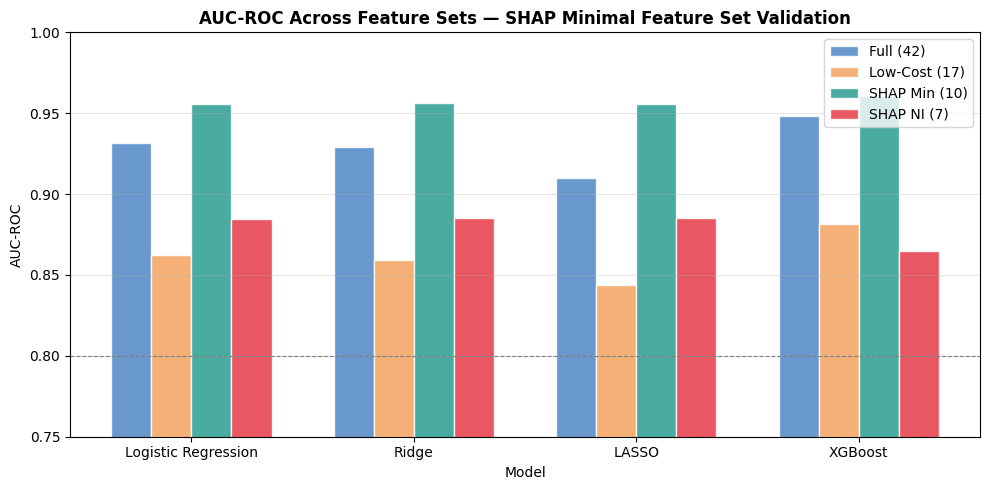

Saved to data/processed/shap_minimal_validation.png


In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

models_list = ['Logistic Regression', 'Ridge', 'LASSO', 'XGBoost']
feature_sets = ['Full (42)', 'Low-Cost (17)', 'SHAP Min (10)', 'SHAP NI (7)']

auc_matrix = []
for model in models_list:
    auc_matrix.append([
        baselines[model]['Full (42)'],
        baselines[model]['Low-Cost (17)'],
        results_10[model][0],
        results_7[model][0],
    ])

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(models_list))
width = 0.18
colors = ['#4F86C6', '#F4A261', '#2a9d8f', '#E63946']

for i, (fs, color) in enumerate(zip(feature_sets, colors)):
    vals = [auc_matrix[j][i] for j in range(len(models_list))]
    ax.bar(x + i * width, vals, width, label=fs, color=color, alpha=0.85, edgecolor='white')

ax.set_xlabel('Model')
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC Across Feature Sets — SHAP Minimal Feature Set Validation', fontweight='bold')
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(models_list)
ax.set_ylim(0.75, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, label='0.8 threshold')

plt.tight_layout()
plt.savefig('../data/processed/shap_minimal_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/processed/shap_minimal_validation.png')

## 12. Classification Threshold Optimisation

The default threshold of 0.5 yields PCOS recall of ~81%, meaning ~1 in 5 true PCOS cases
are missed. In a screening context, false negatives (missed cases) carry a higher cost than
false positives.

This section identifies the threshold that maximises F1-score and separately the threshold
that achieves ≥90% recall, and reports the precision/recall trade-off at each.

Addresses report Section 4.1: *'Adjusting the classification threshold below 0.5 could
increase recall at the cost of precision. This trade-off has not been formally explored.'*

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve, f1_score, roc_curve,
    precision_score, recall_score, confusion_matrix
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/cleaned_data.csv')
df = df.drop(columns=['sl_no', 'patient_file_no'], errors='ignore')
df['ii_beta_hcg_miu_ml'] = pd.to_numeric(df['ii_beta_hcg_miu_ml'], errors='coerce')
df = df.fillna(df.median(numeric_only=True))

full_features = [c for c in df.columns if c != 'pcos_y_n']
low_cost_features = [
    'age_yrs', 'bmi', 'weight_kg', 'waist_hip_ratio',
    'pulse_ratebpm', 'rr_breaths_min', 'cycle_r_i','cycle_lengthdays',
    'bp_systolic_mmhg', 'bp_diastolic_mmhg',
    'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n',
    'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n',
    'reg_exercise_y_n', 'pregnant_y_n'
]

y = df['pcos_y_n']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_full_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(364/177),
        eval_metric='logloss', random_state=42, n_jobs=-1
    ))
])

xgb_low_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(364/177),
        eval_metric='logloss', random_state=42, n_jobs=-1
    ))
])

# Out-of-fold predicted probabilities (avoids train-set optimism)
y_proba_full = cross_val_predict(xgb_full_pipe, df[full_features], y, cv=cv, method='predict_proba')[:, 1]
y_proba_low  = cross_val_predict(xgb_low_pipe,  df[low_cost_features], y, cv=cv, method='predict_proba')[:, 1]

print('Out-of-fold probabilities computed for full and low-cost models.')

Out-of-fold probabilities computed for full and low-cost models.


In [161]:
def threshold_analysis(y_true, y_proba, model_name):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)

    # Best F1 threshold
    best_f1_idx = np.argmax(f1_scores[:-1])  # thresholds has one fewer element
    best_f1_thresh = thresholds[best_f1_idx]

    # Threshold for >=90% recall
    recall_90_idx = np.where(recalls >= 0.90)[0]
    recall_90_thresh = thresholds[recall_90_idx[-1]] if len(recall_90_idx) > 0 else None

    print(f'\n=== {model_name} ===')
    print(f'  Default (0.50):  Precision={precision_score(y_true, y_proba >= 0.50):.3f},  '
          f'Recall={recall_score(y_true, y_proba >= 0.50):.3f},  '
          f'F1={f1_score(y_true, y_proba >= 0.50):.3f}')
    print(f'  Best F1 ({best_f1_thresh:.2f}): Precision={precisions[best_f1_idx]:.3f},  '
          f'Recall={recalls[best_f1_idx]:.3f},  F1={f1_scores[best_f1_idx]:.3f}')
    if recall_90_thresh is not None:
        r90_prec = precision_score(y_true, y_proba >= recall_90_thresh)
        r90_rec  = recall_score(y_true, y_proba >= recall_90_thresh)
        print(f'  ≥90% Recall ({recall_90_thresh:.2f}): Precision={r90_prec:.3f},  '
              f'Recall={r90_rec:.3f}')
    else:
        print('  90% recall threshold: not achievable in this model')

    return precisions, recalls, thresholds, f1_scores, best_f1_thresh, recall_90_thresh

full_pr  = threshold_analysis(y, y_proba_full, 'XGBoost — Full Feature Set')
low_pr   = threshold_analysis(y, y_proba_low,  'XGBoost — Low-Cost Feature Set')


=== XGBoost — Full Feature Set ===
  Default (0.50):  Precision=0.878,  Recall=0.853,  F1=0.865
  Best F1 (0.62): Precision=0.902,  Recall=0.836,  F1=0.868
  ≥90% Recall (0.29): Precision=0.808,  Recall=0.904

=== XGBoost — Low-Cost Feature Set ===
  Default (0.50):  Precision=0.735,  Recall=0.706,  F1=0.720
  Best F1 (0.32): Precision=0.686,  Recall=0.802,  F1=0.740
  ≥90% Recall (0.11): Precision=0.569,  Recall=0.904


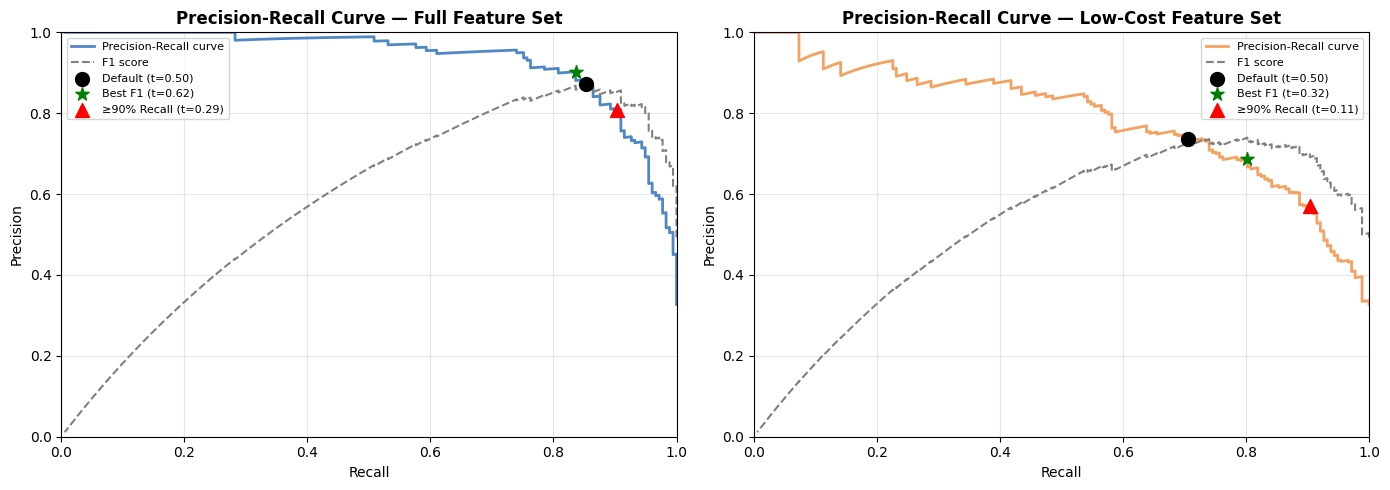

Saved to data/processed/threshold_optimisation.png


In [162]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
BLUE, ORANGE = '#4F86C6', '#F4A261'

for ax, (precisions, recalls, thresholds, f1s, best_f1_t, r90_t), title, color in zip(
    axes,
    [full_pr, low_pr],
    ['Full Feature Set', 'Low-Cost Feature Set'],
    [BLUE, ORANGE]
):
    ax.plot(recalls[:-1], precisions[:-1], color=color, lw=2, label='Precision-Recall curve')
    ax.plot(recalls[:-1], f1s[:-1], color='gray', lw=1.5, linestyle='--', label='F1 score')

    # Mark default threshold
    default_idx = np.argmin(np.abs(thresholds - 0.50))
    ax.scatter(recalls[default_idx], precisions[default_idx],
               s=100, zorder=5, color='black', label=f'Default (t=0.50)')

    # Mark best F1 threshold
    best_f1_idx = np.argmin(np.abs(thresholds - best_f1_t))
    ax.scatter(recalls[best_f1_idx], precisions[best_f1_idx],
               s=100, zorder=5, color='green', marker='*', label=f'Best F1 (t={best_f1_t:.2f})')

    # Mark 90% recall threshold if available
    if r90_t is not None:
        r90_idx = np.argmin(np.abs(thresholds - r90_t))
        ax.scatter(recalls[r90_idx], precisions[r90_idx],
                   s=100, zorder=5, color='red', marker='^', label=f'≥90% Recall (t={r90_t:.2f})')

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall Curve — {title}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../data/processed/threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/processed/threshold_optimisation.png')

## 13. Outlier Sensitivity Analysis

Extreme outliers in `amhng_ml` and the ovarian volume columns were retained without
sensitivity analysis. This section caps outliers at 3 standard deviations, retrains
XGBoost, and compares AUC-ROC and feature rankings to the baseline.

Addresses report Section 4.4 limitation 5: *'Extreme outliers identified during EDA
have been retained without sensitivity analysis.'*

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv('../data/processed/cleaned_data.csv')
df_raw = df_raw.drop(columns=['sl_no', 'patient_file_no'], errors='ignore')
df_raw['ii_beta_hcg_miu_ml'] = pd.to_numeric(df_raw['ii_beta_hcg_miu_ml'], errors='coerce')
df_raw = df_raw.fillna(df_raw.median(numeric_only=True))

# Columns flagged as having extreme outliers
outlier_cols = ['amhng_ml', 'avg_f_size_l_mm', 'avg_f_size_r_mm', 'endometrium_mm',
                'i_beta_hcg_miu_ml', 'ii_beta_hcg_miu_ml']

# Print outlier stats before capping
print('Outlier stats (before capping):')
for col in outlier_cols:
    if col in df_raw.columns:
        mean, std = df_raw[col].mean(), df_raw[col].std()
        cap = mean + 3 * std
        n_outliers = (df_raw[col] > cap).sum()
        print(f'  {col:25s}: mean={mean:.2f}, std={std:.2f}, 3SD cap={cap:.2f}, outliers={n_outliers}')

Outlier stats (before capping):
  amhng_ml                 : mean=5.62, std=5.88, 3SD cap=23.25, outliers=6
  avg_f_size_l_mm          : mean=15.02, std=3.57, 3SD cap=25.72, outliers=0
  avg_f_size_r_mm          : mean=15.45, std=3.32, 3SD cap=25.41, outliers=0
  endometrium_mm           : mean=8.48, std=2.17, 3SD cap=14.97, outliers=4
  i_beta_hcg_miu_ml        : mean=664.55, std=3348.92, 3SD cap=10711.31, outliers=9
  ii_beta_hcg_miu_ml       : mean=238.23, std=1603.83, 3SD cap=5049.71, outliers=3


In [164]:
# Create capped dataset
df_capped = df_raw.copy()
for col in outlier_cols:
    if col in df_capped.columns:
        mean, std = df_raw[col].mean(), df_raw[col].std()
        upper_cap = mean + 3 * std
        lower_cap = mean - 3 * std
        df_capped[col] = df_capped[col].clip(lower=lower_cap, upper=upper_cap)

full_features = [c for c in df_raw.columns if c != 'pcos_y_n']
y = df_raw['pcos_y_n']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(364/177),
        eval_metric='logloss', random_state=42, n_jobs=-1
    ))
])

# Baseline (original data)
auc_baseline = cross_val_score(xgb_pipe, df_raw[full_features], y, cv=cv, scoring='roc_auc')

# Capped data
auc_capped = cross_val_score(xgb_pipe, df_capped[full_features], y, cv=cv, scoring='roc_auc')

print(f'AUC — Original (outliers retained): {auc_baseline.mean():.4f} ± {auc_baseline.std():.4f}')
print(f'AUC — Capped (3 SD):                {auc_capped.mean():.4f} ± {auc_capped.std():.4f}')
print(f'Difference:                          {auc_capped.mean() - auc_baseline.mean():+.4f}')

AUC — Original (outliers retained): 0.9623 ± 0.0123
AUC — Capped (3 SD):                0.9627 ± 0.0121
Difference:                          +0.0004


In [165]:
# Feature importance comparison: original vs capped
from sklearn.model_selection import train_test_split

X_orig_train, _, y_train, _ = train_test_split(
    df_raw[full_features], y, test_size=0.2, stratify=y, random_state=42
)
X_cap_train, _, _, _ = train_test_split(
    df_capped[full_features], y, test_size=0.2, stratify=y, random_state=42
)

pipe_orig = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             scale_pos_weight=(364/177),
                             eval_metric='logloss', random_state=42, n_jobs=-1))
])
pipe_cap = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             scale_pos_weight=(364/177),
                             eval_metric='logloss', random_state=42, n_jobs=-1))
])

pipe_orig.fit(X_orig_train, y_train)
pipe_cap.fit(X_cap_train, y_train)

imp_orig = pd.DataFrame({'Feature': full_features,
                          'Original': pipe_orig.named_steps['model'].feature_importances_})
imp_cap  = pd.DataFrame({'Feature': full_features,
                          'Capped':   pipe_cap.named_steps['model'].feature_importances_})
imp_both = imp_orig.merge(imp_cap, on='Feature').sort_values('Original', ascending=False).head(15)
imp_both['Rank Change'] = (
    imp_both['Original'].rank(ascending=False).astype(int) -
    imp_both['Capped'].rank(ascending=False).astype(int)
)

print('Top 15 Feature Importance — Original vs Capped:')
print(imp_both.to_string(index=False))

Top 15 Feature Importance — Original vs Capped:
           Feature  Original   Capped  Rank Change
     follicle_no_r  0.120590 0.120840            0
     follicle_no_l  0.081658 0.081081            0
   hair_growth_y_n  0.067424 0.066504            0
skin_darkening_y_n  0.047762 0.048098           -1
   weight_gain_y_n  0.047110 0.049537            1
         cycle_r_i  0.046402 0.046327            0
     fast_food_y_n  0.037202 0.035058            0
         weight_kg  0.029223 0.029223           -1
          amhng_ml  0.024216 0.023801           -1
  reg_exercise_y_n  0.023113 0.030453            2
           hipinch  0.023068 0.022072            0
     pulse_ratebpm  0.022081 0.021444            0
  cycle_lengthdays  0.020714 0.020607            0
            fsh_lh  0.019593 0.018575            0
ii_beta_hcg_miu_ml  0.019137 0.018209            0


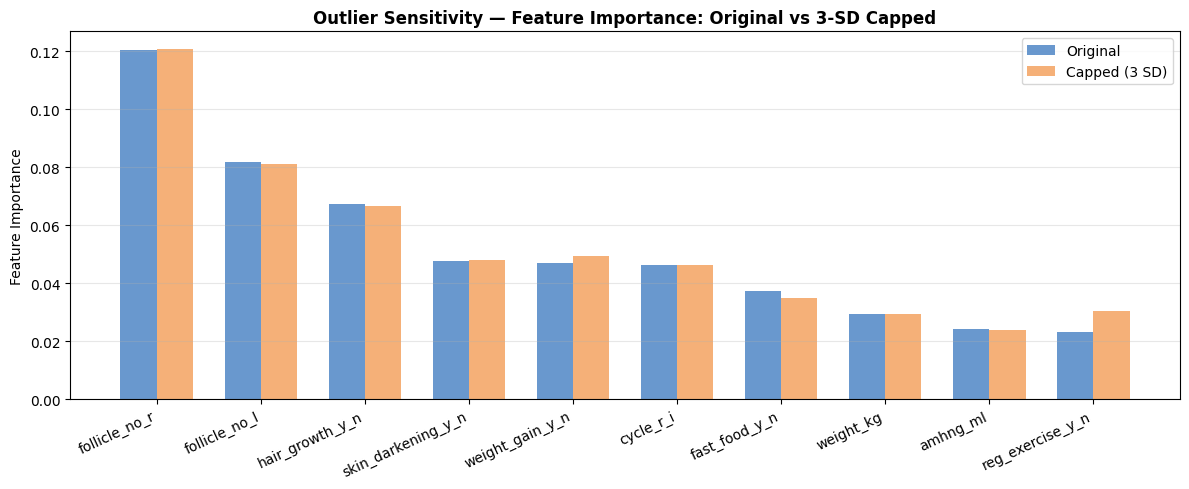

Saved to data/processed/outlier_sensitivity.png

--- Summary ---
AUC change after outlier capping: +0.0004
Results are STABLE — outliers have negligible impact on AUC.


In [166]:
# Bar chart: top 10 feature importances side by side
top10 = imp_both.head(10)
x = np.arange(len(top10))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, top10['Original'], width, label='Original', color='#4F86C6', alpha=0.85)
ax.bar(x + width/2, top10['Capped'],   width, label='Capped (3 SD)', color='#F4A261', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top10['Feature'], rotation=25, ha='right')
ax.set_ylabel('Feature Importance')
ax.set_title('Outlier Sensitivity — Feature Importance: Original vs 3-SD Capped', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/outlier_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/processed/outlier_sensitivity.png')

print('\n--- Summary ---')
delta = auc_capped.mean() - auc_baseline.mean()
print(f'AUC change after outlier capping: {delta:+.4f}')
if abs(delta) < 0.01:
    print('Results are STABLE — outliers have negligible impact on AUC.')
else:
    print('Results CHANGED — outliers meaningfully affect model performance; investigate further.')